# Milestone 1: Data Exploration - Digital Music Reviews

This notebook explores the Amazon Reviews 2023 dataset (Digital Music Category). The goal is to understand the data, select fields for retrieval, preprocess text, and prepare documents in LangChain format for later pipeline stages.

**Data sources**
- Reviews: `Digital_Music.jsonl.gz` — user ratings, text, votes, timestamps  
- Metadata: `meta_Digital_Music.jsonl.gz` — product titles, descriptions, features, price

In [1]:
# imports
from pathlib import Path
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from langchain_core.documents import Document

### Configuration

In [2]:
DATA_DIR = Path("../data")
CATEGORY = "Digital_Music"
BASE_URL = "https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw"
REVIEWS_URL = f"{BASE_URL}/review_categories/{CATEGORY}.jsonl.gz"
META_URL    = f"{BASE_URL}/meta_categories/meta_{CATEGORY}.jsonl.gz"
RAW_DATA_PATH = str((DATA_DIR / "raw" ).resolve())
PROCESSED_DATA_PATH = str((DATA_DIR / "processed" ).resolve())

In [3]:
print(REVIEWS_URL)
print(META_URL)

https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/review_categories/Digital_Music.jsonl.gz
https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/meta_categories/meta_Digital_Music.jsonl.gz


## Initialize an in-memory DB connection

In [4]:
conn = duckdb.connect()

### Schema Preview (remote — no download)

Before downloading, inspect the schema and a few rows directly from the remote `.jsonl.gz` files. DuckDB streams these without a full download.

In [5]:
head_reviews = conn.execute(f"SELECT * FROM read_json_auto('{REVIEWS_URL}') LIMIT 5").df()
head_reviews

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.0,Nice,If i had a dollar for how many times I have pl...,[],B004RQ2IRG,B004RQ2IRG,AFUOYIZBU3MTBOLYKOJE5Z35MBDA,1618972613292,0,True
1,5.0,Excellent,awesome sound - cant wait to see them in perso...,[],B0026UZEI0,B0026UZEI0,AHGAOIZVODNHYMNCBV4DECZH42UQ,1308167525000,0,True
2,5.0,Great service,This is a great cd. Good music and plays well....,[],B0055JSYHC,B0055JSYHC,AFGEM6BXCYHUILEOA3P2ZYBEF2TA,1615838793006,0,True
3,1.0,No good,"These are not real German singers, they have a...",[],B000F9SMUQ,B000F9SMUQ,AH3OG6QD6EDJGZRVCFKV4B66VWNQ,1405219741000,0,True
4,3.0,"Cool concept, so-so execution...",I first heard this playing in a Nagoya shop an...,[],B0049D1WVK,B0049D1WVK,AFW2PDT3AMT4X3PYQG7FJZH5FXFA,1309029595000,0,False


In [6]:
# executes right over the internet -- i just want five rows to preview so doesn't take long
head_meta = conn.execute(f"SELECT * FROM read_json_auto('{META_URL}') LIMIT 5").df()
head_meta

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
0,Digital Music,Baja Marimba Band,4.9,8,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],NaN,[],"{'Date First Available': 'February 28, 2010'}",B000V87RP2,None
1,Digital Music,'80s Halloween-All Original Artists & Recordings,5.0,3,[],[],14.98,[{'thumb': 'https://m.media-amazon.com/images/...,[],"Love and Rockets (Artist), Duran Duran (...",[],{'Package Dimensions': '5.55 x 4.97 x 0.54 inc...,B0062F0MJQ,None
2,Digital Music,TRIO +1,5.0,1,[],[CD ALBUM],57.99,[{'thumb': 'https://m.media-amazon.com/images/...,[],Rob Wasserman Format: Audio CD,[],"{'Is Discontinued By Manufacturer': 'No', 'Pac...",B00005GT12,None
3,Digital Music,"Gold and Silver: Lehar, Delibes, Lanner, Johan...",5.0,1,[],[],29.91,[{'thumb': 'https://m.media-amazon.com/images/...,[],"Franz Lehar (Composer), Leo Delibes (Com...",[],"{'Manufacturer': 'Hungaroton / White Label', '...",B0007PD2BW,None
4,Digital Music,Grateful Dead Dave's Picks Volume 25 Live at B...,4.9,20,[],[Sold out. Numbered limited edition],149.99,[{'thumb': 'https://m.media-amazon.com/images/...,[],"Grateful Dead (Artist, Orchestra) Format: ...",[],{'Package Dimensions': '5.55 x 4.97 x 0.54 inc...,B079CPD45R,None


Count the number of products and reviews:

In [7]:
# Unique products in metadata
n_products = conn.execute(f"""
    SELECT COUNT(DISTINCT parent_asin) 
    FROM read_json_auto('{META_URL}')
""").fetchone()[0]

# Total reviews
n_reviews = conn.execute(f"""
    SELECT COUNT(*) 
    FROM read_json_auto('{REVIEWS_URL}')
""").fetchone()[0]

print(f"Unique products (meta): {n_products:,}")
print(f"Total reviews:          {n_reviews:,}")

Unique products (meta): 70,537
Total reviews:          130,434


## Download and convert to parquet file

Downloading the full Digital Music dataset (~130K reviews, ~70K products). This streams directly from the remote source and takes 5-10 minutes.

In [8]:
conn.execute(f"""
      COPY (SELECT * FROM read_json_auto('{REVIEWS_URL}'))
      TO '{RAW_DATA_PATH}/reviews_raw.parquet'
      (FORMAT PARQUET, COMPRESSION ZSTD)
  """)

In [9]:
conn.execute(f"""
      COPY (SELECT * FROM read_json_auto('{META_URL}'))
      TO '{RAW_DATA_PATH}/meta_raw.parquet'
      (FORMAT PARQUET, COMPRESSION ZSTD)
  """)

## Merging the two files by joining on `parent_asin`

A `LEFT JOIN` is used to retain all reviews even if their product has no metadata entry.

In [10]:
conn.execute(f"""
    COPY (
        SELECT r.*, m.title AS product_title,
            m.average_rating, m.rating_number, m.features, 
            m.description, m.price, m.store, m.main_category,
            m.categories, m.details, m.bought_together
        FROM read_parquet('{RAW_DATA_PATH}/reviews_raw.parquet') r
        LEFT JOIN read_parquet('{RAW_DATA_PATH}/meta_raw.parquet') m USING (parent_asin)
    )
    TO '{PROCESSED_DATA_PATH}/merged.parquet' (FORMAT PARQUET, COMPRESSION ZSTD)
""")

### Stratified Sampling

A simple `LIMIT` would return the first N rows - likely dominated by one time period or product cluster. Instead, we sample across three dimensions to ensure diversity:

- **`rating_bucket`**: product quality tier (6 buckets based on `average_rating`)  
- **`len_tier`**: review length - `short` (<100 chars), `medium` (<500), `long` (≥500)  
- **`verified_purchase`**: purchase verification status

Within each stratum cell, one review is selected per product (prioritising helpful votes), then up to `SAMPLE_PER_STRATUM` reviews are kept. This gives a balanced dataset that covers the full diversity of products and review styles.


In [11]:
# Stratified sampling parameters
SAMPLE_PER_STRATUM = 1   # reviews per stratum cell
MIN_TEXT_LEN       = 10   # drop near-empty reviews (chars)
SHORT_MAX          = 100  # short: text < SHORT_MAX chars
MEDIUM_MAX         = 500  # medium: SHORT_MAX ≤ text < MEDIUM_MAX

In [12]:
conn.execute("SELECT setseed(0.42)")
conn.execute(f"""
COPY (
WITH labelled AS (
    SELECT
        mp.*,

        CASE
            WHEN average_rating >= 4.6 THEN '4.6-5.0'
            WHEN average_rating >= 4.4 THEN '4.4-4.5'
            WHEN average_rating >= 4.1 THEN '4.1-4.3'
            WHEN average_rating >= 3.7 THEN '3.7-4.0'
            WHEN average_rating >= 3.1 THEN '3.1-3.6'
            ELSE                              '<=3.0'
        END AS rating_bucket,

        CASE
            WHEN LENGTH(text) < {SHORT_MAX}  THEN 'short'
            WHEN LENGTH(text) < {MEDIUM_MAX} THEN 'medium'
            ELSE                                    'long'
        END AS len_tier

    FROM read_parquet('{PROCESSED_DATA_PATH}/merged.parquet') mp
    WHERE text IS NOT NULL
      AND LENGTH(text) >= {MIN_TEXT_LEN}
      AND average_rating IS NOT NULL
),
one_per_product AS (
    SELECT *,
        ROW_NUMBER() OVER (
            PARTITION BY parent_asin
            ORDER BY helpful_vote DESC, random()
        ) AS product_rank
    FROM labelled
)
SELECT * EXCLUDE (product_rank)
FROM one_per_product
WHERE product_rank = {SAMPLE_PER_STRATUM}
)
TO '{PROCESSED_DATA_PATH}/stratified_sample.parquet' (FORMAT PARQUET, COMPRESSION ZSTD)
""")

In [13]:
# read the stratified parquet file back into a dataframe to preview
df_eda = conn.execute(f"SELECT * FROM read_parquet('{PROCESSED_DATA_PATH}/stratified_sample.parquet')").df()
df_eda.shape

(67678, 23)

### Stratum Distribution

Verify the sampling worked - each cell should have up to `SAMPLE_PER_STRATUM` rows.

In [14]:
df_eda.groupby(['rating_bucket', 'len_tier', 'verified_purchase']).size().unstack(fill_value=0)

verified_purchase       False  True 
rating_bucket len_tier              
3.1-3.6       long        269    141
              medium      277    507
              short        70    387
3.7-4.0       long       1348    513
              medium      991   1517
              short       182   1167
4.1-4.3       long        735    334
              medium      558   1195
              short       160   1085
4.4-4.5       long       1120    585
              medium      880   1915
              short       246   2020
4.6-5.0       long       6341   2802
              medium     6766  13106
              short      1870  14821
<=3.0         long        727    285
              medium      646   1184
              short       179    749

## EDA - Dataset overview (fields, types, size)

In [15]:
print(f"Stratified sample shape: {df_eda.shape}")
print("\nColumn Types:")
print(df_eda.dtypes)
print("\nNull values per column:")
print(df_eda.isnull().sum())
df_eda.apply(
    lambda col: col.apply(
        lambda x: isinstance(x, (list, np.ndarray)) and len(x) == 0
    ).sum()
)

Stratified sample shape: (67678, 23)

Column Types:
rating               float64
title                    str
text                     str
images                object
asin                     str
parent_asin              str
user_id                  str
timestamp              int64
helpful_vote           int64
verified_purchase       bool
product_title            str
average_rating       float64
rating_number          int64
features              object
description           object
price                float64
store                    str
main_category            str
categories            object
details               object
bought_together       object
rating_bucket            str
len_tier                 str
dtype: object

Null values per column:
rating                   0
title                    0
text                     0
images                   0
asin                     0
parent_asin              0
user_id                  0
timestamp                0
helpful_vote             0

rating                   0
title                    0
text                     0
images               65664
asin                     0
parent_asin              0
user_id                  0
timestamp                0
helpful_vote             0
verified_purchase        0
product_title            0
average_rating           0
rating_number            0
features             67608
description          40616
price                    0
store                    0
main_category            0
categories           67671
details                  0
bought_together          0
rating_bucket            0
len_tier                 0
dtype: int64

In [16]:
# Structured sample — one full record
df_eda.iloc[0].to_dict()

{'rating': 5.0,
 'title': 'Amazing!',
 'text': "So of course if you're a fan you're gonna love this either way but oh my word. This came on time in great condition. And the set was just super amazing. It came with a cute bunch of little goodies. The poster is cute so is the signed Hobi card I got. All in all would definitely recommend.",
 'images': array([], dtype=object),
 'asin': 'B06X1885N6',
 'parent_asin': 'B06X1885N6',
 'user_id': 'AEFWJVQSE7TNJE42RI4Z5XGSN3OQ',
 'timestamp': 1497006568000,
 'helpful_vote': 2,
 'verified_purchase': True,
 'product_title': 'BTS Wings You never walk alone Kpop Bangtan Boys [Left Ver.] Album CD + Photobook + Photocard + Gift (4 Photocards Set)',
 'average_rating': 4.8,
 'rating_number': 1739,
 'features': array([], dtype=object),
 'description': array(['Your purchase quantity will be count on Korea Hanteo, Gaon Charts and K-Charts !! This package consists of : BTS WINGS YOU NEVER WALK ALONE KPOP BANGTAN BOYS [LEFT Ver.] Album CD + 120page Photobook 

In [17]:
# Tabular preview
df_eda[['product_title', 'verified_purchase', 'rating', 'title', 'text', 'average_rating']].head()

,product_title,verified_purchase,rating,title,text,average_rating
0,BTS Wings You never walk alone Kpop Bangtan Bo...,True,5.0,Amazing!,So of course if you're a fan you're gonna love...,4.8
1,Milestones Of A Legend,True,5.0,Top of the line,If you want to get some great Coleman Hawkins ...,4.6
2,Ultimate Collection,True,5.0,Five Stars,"Awesome cd, fast shipping. Ty",5.0
3,Always By Lee Min Ho,True,5.0,Good.,The CD comes in a 9.5 x 12.5&#34; folder type ...,4.5
4,The Game Begins With The Lights Out,True,5.0,ELO/Badfinger and 10cc sounds of HORNAL.,Iain HORNAL plays with both Jeff Lynne's ELO a...,3.9


### Rating distribution

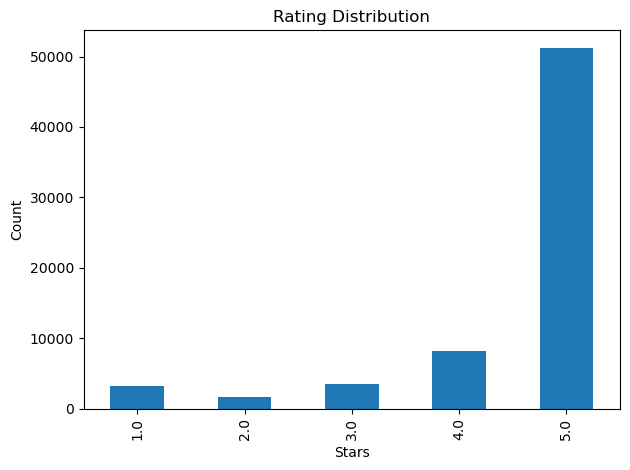

In [18]:
df_eda['rating'].value_counts().sort_index().plot(kind='bar', title='Rating Distribution')
plt.xlabel('Stars'); 
plt.ylabel('Count'); 
plt.tight_layout(); 
plt.show()

### Field selection and justification

Fields to KEEP for retrieval:

|Field|Source file|Why keep|
|---|---|---|
|text|review|Primary retrieval content — user-written review|
|title (review title)|review|Short query-style text, useful for matching|
|rating|review|Signal for relevance filtering|
|verified_purchase|review|Trust signal for ranking|
|helpful_vote|review|Proxy for review quality|
|product_title|metadata|Query-side matching|
|parent_asin|both|Key for document identity|
|description|meta|Rich product content for retrieval|
|features|meta|Structured product attributes|
|main_category|meta|Facet filtering|
|price|meta|Facet filtering|
|store|meta|Facet filtering|
|average_rating|meta|Product-level quality signal|

Fields to drop: 

|Field|Reason|
|---|---|
|timestamp|Temporal metadata not needed for semantic retrieval|
|user_id|User identity irrelevant for retrieval|
|asin|Redundant — parent_asin is the canonical product key|
|images (both files)|Binary/URL data, not useful for text retrieval|
|videos|Same as above|
|categories|Redundant with main_category unless we need multi-level taxonomy (is currently empty in our eda dataframe)|
|details|Semi-structured key-value dict — low signal, hard to index cleanly|
|rating_number|Product-level count, not meaningful per document|
|bought_together|Popularity signal, not retrieval-relevant|

In [19]:
RETRIEVAL_FIELDS = [
    'parent_asin', 'text', 'title',        # review fields
    'rating', 'verified_purchase', 'helpful_vote',
    'product_title', 'description', 'features',  # meta fields
    'main_category', 'price', 'store', 'average_rating',
    'rating_bucket', 'len_tier'   
]
df_eda[RETRIEVAL_FIELDS].dropna(subset=['text']).head()

,parent_asin,text,title,rating,verified_purchase,helpful_vote,product_title,description,features,main_category,price,store,average_rating,rating_bucket,len_tier
0,B06X1885N6,So of course if you're a fan you're gonna love...,Amazing!,5.0,True,2,BTS Wings You never walk alone Kpop Bangtan Bo...,[Your purchase quantity will be count on Korea...,[],Digital Music,26.71,BTS Format: Audio CD,4.8,4.6-5.0,medium
1,B06XB2ZQL5,If you want to get some great Coleman Hawkins ...,Top of the line,5.0,True,0,Milestones Of A Legend,[10 CD box set of seventeen original albums fr...,[],Digital Music,NaN,Coleman Hawkins Format: Audio CD,4.6,4.6-5.0,short
2,B06XDM5S1D,"Awesome cd, fast shipping. Ty",Five Stars,5.0,True,0,Ultimate Collection,[],[],Digital Music,NaN,VELVET UNDERGROUND (Artist) Format: Audio CD,5.0,4.6-5.0,short
3,B06XG3Y9FD,The CD comes in a 9.5 x 12.5&#34; folder type ...,Good.,5.0,True,4,Always By Lee Min Ho,"[A single ""Always"" released by Korea's popular...",[],Digital Music,19.00,Lee Minho Format: Audio CD,4.5,4.4-4.5,medium
4,B06XRNCFRJ,Iain HORNAL plays with both Jeff Lynne's ELO a...,ELO/Badfinger and 10cc sounds of HORNAL.,5.0,True,0,The Game Begins With The Lights Out,[],[],Digital Music,149.00,Hornal (Artist) Format: Audio CD,3.9,3.7-4.0,medium


### Text Preprocessing

Three transformations applied to the `text` field:

| Step | Decision | Rationale |
|---|---|---|
| Strip HTML tags | Remove `<br>`, `<b>` etc. | Some reviews contain raw HTML that adds noise |
| Lowercase | Normalize all text | Reduces vocabulary size; `Great` and `great` are the same token |
| Collapse whitespace | Trim and deduplicate spaces | Cleans artifacts from HTML removal |

Fields like `description` and `features` are kept raw in metadata — preprocessing is only applied to the `text` field used as `page_content` in retrieval.

In [20]:
# Confirm HTML tags exist in the data to justify the stripping step
df_eda[df_eda['text'].str.contains(r"<[^>]+>", regex=True, na=False)].head(3)

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,...,features,description,price,store,main_category,categories,details,bought_together,rating_bucket,len_tier
8,5.0,Everything from design to music is A+,This album is a great followup to the group's ...,[],B06Y4LMK5N,B06Y4LMK5N,AFF3HSIMCMX4WQJAVUVCK6YZOGOQ,1500910173840,1,True,...,[],[],NaN,Format: Audio CD,Digital Music,[],{'Package Dimensions': '8.5 x 5.91 x 0.59 inch...,None,4.6-5.0,long
11,4.0,A treasure,A marvelous recording and artist I turned onto...,[],B06ZZWD79B,B06ZZWD79B,AH52OPJKMTXQVZ7WWB2AW6WSSUDA,1525617581655,2,False,...,[],[],NaN,Akua Dixon (Artist) Format: Audio CD,Digital Music,[],"{'Package Dimensions': '7 x 7 x 1 inches', 'Ma...",None,4.6-5.0,long
12,4.0,You can count me in,"Apart from the first two tracks, for the rest ...",[],B0711MB8W7,B0711MB8W7,AE4SYLXUCYQA4L4F34BKFNWKM6BA,1494759306000,0,False,...,[],"[European release, 3CD boxset. Tracklist - CD1...",36.99,Paul Weller (Artist) Format: Audio CD,Digital Music,[],{'Manufacturer': 'Parlophone (Warner Music EU)...,None,4.6-5.0,long


In [21]:
# preprocessing function for text data
def preprocess_text(text: str) -> str:
    """
    Decisions:
    - Strip HTML tags (some reviews contain <br> etc.)
    - Lowercase for vocabulary normalization
    - Collapse whitespace
    """
    text = re.sub(r'<[^>]+>', ' ', str(text))   # remove HTML
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_eda = df_eda.copy()
df_eda['text_clean'] = df_eda['text'].apply(preprocess_text)
df_eda[['text', 'text_clean']].head(3)  # before/after preview

,text,text_clean
0,So of course if you're a fan you're gonna love...,so of course if you're a fan you're gonna love...
1,If you want to get some great Coleman Hawkins ...,if you want to get some great coleman hawkins ...
2,"Awesome cd, fast shipping. Ty","awesome cd, fast shipping. ty"


In [22]:
# Save df_eda (all fields + text_clean) to document.parquet
df_eda.to_parquet(f"{PROCESSED_DATA_PATH}/documents.parquet", compression="zstd", index=False)
print(f"Saved {df_eda.shape[0]} rows with {df_eda.shape[1]} columns to documents.parquet")

Saved 67678 rows with 24 columns to documents.parquet


In [24]:
df = pd.read_parquet(f"{PROCESSED_DATA_PATH}/documents.parquet")
print(f"Documents: {len(df):,}") 
print(f"Unique products: {df['parent_asin'].nunique():,}")

Documents: 67,678
Unique products: 67,678


### LangChain Document format

`features` and `description` are numpy.ndarray columns. LangChain's Document metadata must be JSON-serializable. `safe_metadata` function will fix any serialization error.

In [23]:
def safe_metadata(row, fields):
    result = {}
    for k in fields:
        if k == 'text':
            continue
        v = row[k]
        if isinstance(v, np.ndarray):
            v = v.tolist()
        result[k] = v
    return result

documents = [
    Document(
        page_content=row['text_clean'],
        metadata=safe_metadata(row, RETRIEVAL_FIELDS)
    )
    for _, row in df_eda.iterrows()
]

# Preview
print(documents[0].page_content[:300])
print(documents[0].metadata)

so of course if you're a fan you're gonna love this either way but oh my word. this came on time in great condition. and the set was just super amazing. it came with a cute bunch of little goodies. the poster is cute so is the signed hobi card i got. all in all would definitely recommend.
{'parent_asin': 'B06X1885N6', 'title': 'Amazing!', 'rating': 5.0, 'verified_purchase': True, 'helpful_vote': 2, 'product_title': 'BTS Wings You never walk alone Kpop Bangtan Boys [Left Ver.] Album CD + Photobook + Photocard + Gift (4 Photocards Set)', 'description': ['Your purchase quantity will be count on Korea Hanteo, Gaon Charts and K-Charts !! This package consists of : BTS WINGS YOU NEVER WALK ALONE KPOP BANGTAN BOYS [LEFT Ver.] Album CD + 120page Photobook + Photocard (Random 1 out of 8) + 4 Photocards Set ★Track List: 01. Intro : Boy Meets Evil 02. 피 땀 눈물 03. Begin 04. Lie 05. Stigma 06. First Love 07. Reflection 08. MAMA 09. Awake 10. Lost 11. BTS Cypher 4 12. Am I Wrong 13. 21세기 소녀 14. 둘! 셋!

## Summary

| Artifact | Path | Description |
|---|---|---|
| `reviews_raw.parquet` | `data/raw/` | Full Digital Music reviews (~130K rows) |
| `meta_raw.parquet` | `data/raw/` | Full Digital Music metadata (~70K products) |
| `merged.parquet` | `data/processed/` | Full join of reviews + metadata |
| `stratified_sample.parquet` | `data/processed/` | 1 best review per unique product (~67K rows) |
|`documents.parquet`|`data/processed/`|1-review-per-product sample + text_clean - input to BM25 index and FAISS indexes|

The `documents` list is ready for ingestion.
Each document's `page_content` is the cleaned review text, `metadata` carries all retrieval-relevant fields for filtering and ranking.